<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria-de-aprendizaje-de-maquina/blob/main/PARCIAL2TAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resumen de Redes Neuronales Implementadas a Mano

## 1. Objetivo del ejercicio

Se desea aproximar una función desconocida a partir de ejemplos de entrada y salida.

Se generan datos mediante:

$$
f(x_1,x_2)=\max\left(0,\;1.5+2\sin(\pi x_1)+0.75x_2^2-1.2x_1x_2\right)
$$

y posteriormente:

$$
y=\max(0,f(x_1,x_2)+\epsilon)
$$

donde:

$$
\epsilon \sim N(0,0.15^2)
$$

La red neuronal NO conoce la ecuación anterior.

La red únicamente observa ejemplos del tipo:

```text
(x1,x2) -> y
```

y debe aprender la relación existente entre las entradas y la salida.

---

# 2. ¿Qué aprende realmente una red neuronal?

La red NO aprende la ecuación explícita.

Por ejemplo, la red nunca ve:

$$
1.5+2\sin(\pi x_1)+0.75x_2^2-1.2x_1x_2
$$

La red solamente observa ejemplos:

```text
(0.5, -1.2) -> 2.7
(1.3, 0.8)  -> 1.4
...
```

A partir de estos datos construye internamente una función:

$$
\hat y = NN(x_1,x_2)
$$

ajustando sus pesos para que:

$$
\hat y \approx y
$$

---

# 3. Arquitectura de la red

La arquitectura utilizada fue:

```text
2 entradas
    ↓
2 neuronas
    ↓
2 neuronas
    ↓
1 salida
```

o equivalentemente:

```text
2 → 2 → 2 → 1
```

La red contiene:

- Capa de entrada
- Primera capa oculta
- Segunda capa oculta
- Capa de salida

---

# 4. ¿Qué son los pesos?

Los pesos representan la importancia de cada conexión.

Ejemplo:

$$
z_1=w_{11}x_1+w_{12}x_2+b_1
$$

donde:

- $$w_{11}$$ controla la influencia de $$x_1$$
- $$w_{12}$$ controla la influencia de $$x_2$$

Durante el entrenamiento estos valores cambian constantemente.

---

# 5. Forward Propagation

Es el proceso mediante el cual la información avanza desde la entrada hasta la salida.

Ejemplo:

$$
z_1=w_{11}x_1+w_{12}x_2+b_1
$$

$$
a_1=ReLU(z_1)
$$

Luego las activaciones alimentan la siguiente capa hasta obtener:

$$
\hat y
$$

que representa la predicción de la red.

---

# 6. Función ReLU

La función de activación utilizada fue:

$$
ReLU(z)=\max(0,z)
$$

Por lo tanto:

Si:

$$
z>0
$$

entonces:

$$
ReLU(z)=z
$$

Si:

$$
z\le 0
$$

entonces:

$$
ReLU(z)=0
$$

---

# 7. ¿Por qué se utiliza ReLU?

Sin funciones de activación todas las capas serían equivalentes a una sola transformación lineal.

La red no podría aprender funciones complejas.

ReLU introduce no linealidad permitiendo aproximar:

- Funciones seno
- Funciones cuadráticas
- Interacciones entre variables

Aunque ReLU es lineal por partes, muchas neuronas ReLU juntas pueden aproximar curvas complejas.

---

# 8. Derivada de ReLU

Durante backpropagation se utiliza:

$$
ReLU'(z)=
\begin{cases}
1 & z>0\\
0 & z\le0
\end{cases}
$$

Esto permite calcular cómo cambia el error respecto a cada peso.

---

# 9. Función de pérdida (Loss)

Se utilizó:

$$
L=\frac12(y-\hat y)^2
$$

donde:

- $$y$$ es el valor real
- $$\hat y$$ es la predicción

La pérdida mide qué tan equivocada está la red.

---

# 10. Backpropagation

Backpropagation consiste en propagar el error desde la salida hacia las capas anteriores.

Pregunta que responde:

> ¿Qué peso contribuyó al error y cuánto debe corregirse?

Se calculan gradientes para cada peso de la red.

---

# 11. Gradiente

El gradiente indica:

> ¿Cómo cambia el error si modifico ligeramente un peso?

Matemáticamente:

$$
\frac{\partial L}{\partial w}
$$

Si el gradiente es grande:

- el peso debe cambiar más

Si es pequeño:

- el peso debe cambiar poco

---

# 12. Actualización de pesos

La forma clásica es:

$$
w_{nuevo}=w_{viejo}-\eta \frac{\partial L}{\partial w}
$$

donde:

$$
\eta
$$

es el learning rate.

En el código:

```python
w -= lr*grad
```

---

# 13. Relación con la fórmula del profesor

A veces se escribe:

$$
w_{nuevo}=w_{viejo}+\lambda\nabla w
$$

donde:

$$
\nabla w=
-\frac{\partial L}{\partial w}
$$

Sustituyendo:

$$
w_{nuevo}
=
w_{viejo}
-\lambda\frac{\partial L}{\partial w}
$$

Por lo tanto ambas expresiones son equivalentes.

---

# 14. Learning Rate

El learning rate controla el tamaño del paso de aprendizaje.

$$
lr=\eta
$$

---

## Learning rate pequeño

Ejemplo:

```python
lr=0.000001
```

Ventajas:

- Muy estable

Desventajas:

- Aprende extremadamente lento

---

## Learning rate adecuado

Ejemplo:

```python
lr=0.001
```

Ventajas:

- Aprendizaje estable
- Convergencia razonable

---

## Learning rate demasiado grande

Ejemplo:

```python
lr=1
```

Problemas:

- Saltos muy grandes
- Oscilaciones
- Divergencia
- El entrenamiento puede explotar

---

# 15. ¿Qué significa que la red explote?

Significa que el error crece en lugar de disminuir.

Ejemplo:

```text
Epoch 0 : Loss = 3
Epoch 1 : Loss = 20
Epoch 2 : Loss = 500
Epoch 3 : Loss = 10000
```

En este caso el aprendizaje se vuelve inestable.

---

# 16. Épocas

Una época significa:

> La red ve todos los ejemplos de entrenamiento una vez.

En el ejercicio:

```python
n=3000
```

Se generaron 3000 observaciones.

Posteriormente:

```python
80% entrenamiento
20% prueba
```

Por lo tanto:

```text
2400 entrenamiento
600 prueba
```

Si:

```python
epocas=300
```

entonces la red recorre:

$$
2400\times300
=
720000
$$

ejemplos durante todo el entrenamiento.

---

# 17. ¿Qué ocurre con los 600 datos de prueba?

Los 600 datos NO participan en el aprendizaje.

Se utilizan únicamente para evaluar la calidad del modelo.

Es decir:

```text
2400 datos -> aprender
600 datos  -> examinar
```

Esto permite verificar si la red generaliza correctamente.

---

# 18. Métricas de evaluación

## MSE

Mean Squared Error:

$$
MSE=
\frac1n
\sum
(y-\hat y)^2
$$

Penaliza fuertemente errores grandes.

Mientras más cercano a cero, mejor.

---

## RMSE

Root Mean Squared Error:

$$
RMSE=\sqrt{MSE}
$$

Tiene las mismas unidades que la variable objetivo.

---

## MAE

Mean Absolute Error:

$$
MAE=
\frac1n
\sum
|y-\hat y|
$$

Representa el error promedio cometido por la red.

---

## R²

Coeficiente de determinación:

$$
R^2
$$

Valores típicos:

- $$R^2=1$$ → perfecto
- $$R^2=0$$ → equivalente a usar el promedio
- $$R^2<0$$ → peor que el promedio

Interpretación:

$$
R^2=0.95
$$

significa que el modelo explica aproximadamente el 95% de la variabilidad de los datos.

---

# 19. Interpretación de las gráficas

## Curva de entrenamiento

Muestra:

```text
Loss vs Época
```

Si el loss disminuye:

```text
2.99 → 1.71
```

la red está aprendiendo.

---

## Observado vs Predicho

Eje X:

$$
y
$$

(valor real)

Eje Y:

$$
\hat y
$$

(predicción)

La línea diagonal representa:

$$
y=\hat y
$$

Predicción perfecta.

Cuanto más cerca estén las bolitas de la diagonal, mejor es el modelo.

---

## Señal real vs Predicho

Eje X:

$$
f(x_1,x_2)
$$

Eje Y:

$$
\hat y
$$

Permite evaluar qué tan bien la red aprendió la función verdadera sin ruido.

---

# 20. Conclusiones obtenidas

- La implementación manual de forward propagation es correcta.
- La implementación manual de backpropagation es correcta.
- La actualización de pesos es correcta.
- La disminución del loss demuestra aprendizaje.
- El learning rate utilizado es estable.
- El bajo valor de R² no implica un error en la implementación.
- La arquitectura 2→2→2→1 tiene capacidad limitada para aproximar funciones complejas.
- Incrementar neuronas o capas puede mejorar la capacidad de representación.
- Una red puede estar correctamente implementada y aun así obtener un desempeño moderado debido a limitaciones de arquitectura.
- El objetivo principal del ejercicio es demostrar comprensión de los fundamentos de aprendizaje profundo:
  - Forward propagation
  - ReLU
  - Loss
  - Gradientes
  - Backpropagation
  - Actualización de pesos
  - Evaluación mediante métricas

Dimensión X: (3000, 2)
y: min=0.000, max=10.124, media=2.637
Epoch   0 | Loss = 2.802139
Epoch  10 | Loss = 1.724569
Epoch  20 | Loss = 1.703476
Epoch  30 | Loss = 1.701363
Epoch  40 | Loss = 1.700790
Epoch  50 | Loss = 1.700350
Epoch  60 | Loss = 1.699944
Epoch  70 | Loss = 1.699592
Epoch  80 | Loss = 1.699283
Epoch  90 | Loss = 1.698984

===== MÉTRICAS vs OBSERVADO =====
  MSE  : 3.3895
  RMSE : 1.8411
  MAE  : 1.3852
  R²   : 0.2420

===== MÉTRICAS vs SEÑAL REAL =====
  MSE  : 3.4176
  RMSE : 1.8487
  MAE  : 1.3898
  R²   : 0.2428


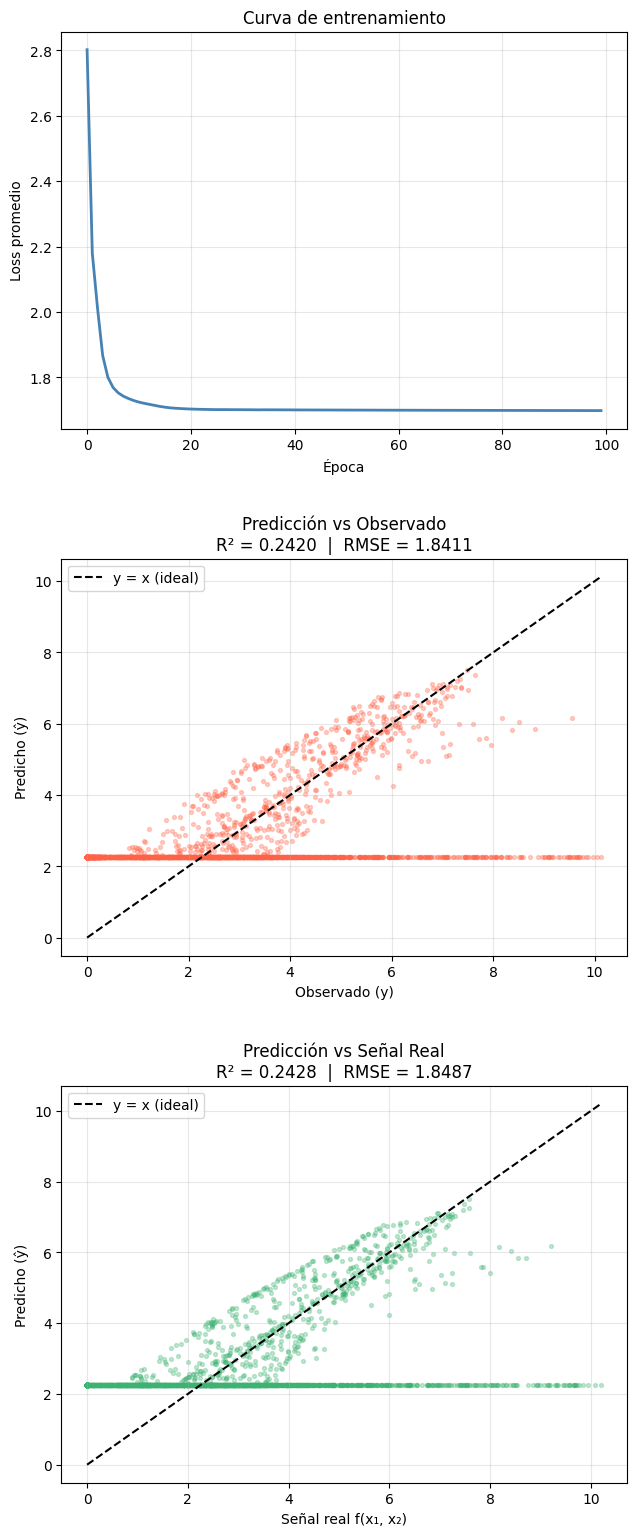

Gráfica guardada en: /content/red_neuronal_resultados.png


In [ ]:
"""
Red neuronal a pedal — 2 entradas, 2 capas ocultas (2 neuronas c/u), 1 salida
Activación ReLU en todas las capas, incluida la salida.
Regla de actualización: w_new = w_old + λ * ∇w
   donde ∇w = -dL/dw  (gradiente negativo de la pérdida)
   → equivalente a descenso por gradiente estándar.
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# ETAPA 1-3. Datos
# ============================================================
np.random.seed(123)
n = 3000

x1 = np.random.uniform(-2, 2, n)
x2 = np.random.uniform(-2, 2, n)
epsilon = np.random.normal(loc=0, scale=0.15, size=n)

f_real = np.maximum(
    0,
    1.5 + 2*np.sin(np.pi*x1) + 0.75*x2**2 - 1.2*x1*x2
)
y = np.maximum(0, f_real + epsilon)
X = np.column_stack((x1, x2))
print("Dimensión X:", X.shape)
print(f"y: min={y.min():.3f}, max={y.max():.3f}, media={y.mean():.3f}")

# ============================================================
# ETAPA 5-6. Arquitectura e inicialización
# ============================================================
np.random.seed(42)

# Primera capa oculta
w11 = np.random.uniform(-0.5, 0.5); w21 = np.random.uniform(-0.5, 0.5)
w12 = np.random.uniform(-0.5, 0.5); w22 = np.random.uniform(-0.5, 0.5)
b1 = 0.0; b2 = 0.0

# Segunda capa oculta
v11 = np.random.uniform(-0.5, 0.5); v21 = np.random.uniform(-0.5, 0.5)
v12 = np.random.uniform(-0.5, 0.5); v22 = np.random.uniform(-0.5, 0.5)
b3 = 0.0; b4 = 0.0

# Capa de salida
u1 = np.random.uniform(-0.5, 0.5); u2 = np.random.uniform(-0.5, 0.5)
b5 = 0.0

# ============================================================
# ETAPA 7-8. Activaciones
# ============================================================
def relu(z):
    return max(0.0, z)

def drelu(z):
    return 1.0 if z > 0 else 0.0

# ============================================================
# ETAPA 13. Ciclo de entrenamiento
# ============================================================
epocas = 100
lr = 0.001        # lr más alto para converger en 100 épocas
historial = []

for epoch in range(epocas):
    error_total = 0.0

    for i in range(n):

        # ------ DATOS ------
        x1_i = X[i, 0]
        x2_i = X[i, 1]
        y_i  = y[i]

        # ------ FORWARD ------
        z1 = w11*x1_i + w21*x2_i + b1;  h1 = relu(z1)
        z2 = w12*x1_i + w22*x2_i + b2;  h2 = relu(z2)

        z3 = v11*h1 + v21*h2 + b3;      h3 = relu(z3)
        z4 = v12*h1 + v22*h2 + b4;      h4 = relu(z4)

        z5 = u1*h3 + u2*h4 + b5;        y_hat = relu(z5)

        # ------ LOSS L = ½(y - ŷ)² ------
        L = 0.5*(y_i - y_hat)**2
        error_total += L

        # ------ BACKPROP ------
        # dL/dŷ = -(y - ŷ)  →  multiplicado por drelu(z5)
        delta5 = -(y_i - y_hat) * drelu(z5)   # = dL/dz5

        # Gradientes dL/dw (usamos el signo real de la derivada)
        du1 = delta5 * h3
        du2 = delta5 * h4
        db5 = delta5

        delta3 = delta5 * u1 * drelu(z3)
        delta4 = delta5 * u2 * drelu(z4)

        dv11 = delta3 * h1;  dv21 = delta3 * h2
        dv12 = delta4 * h1;  dv22 = delta4 * h2
        db3 = delta3;        db4 = delta4

        delta1 = (delta3*v11 + delta4*v12) * drelu(z1)
        delta2 = (delta3*v21 + delta4*v22) * drelu(z2)

        dw11 = delta1 * x1_i;  dw21 = delta1 * x2_i
        dw12 = delta2 * x1_i;  dw22 = delta2 * x2_i
        db1 = delta1;           db2 = delta2

        # ------ ACTUALIZACIÓN: w_new = w_old + λ * ∇w ------
        # ∇w definido como el NEGATIVO del gradiente de la pérdida
        # → w_new = w_old - λ * dL/dw  ← descenso por gradiente
        u1  += -lr * du1;   u2  += -lr * du2;   b5  += -lr * db5

        v11 += -lr * dv11;  v21 += -lr * dv21
        v12 += -lr * dv12;  v22 += -lr * dv22
        b3  += -lr * db3;   b4  += -lr * db4

        w11 += -lr * dw11;  w21 += -lr * dw21
        w12 += -lr * dw12;  w22 += -lr * dw22
        b1  += -lr * db1;   b2  += -lr * db2

    loss_epoch = error_total / n
    historial.append(loss_epoch)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss = {loss_epoch:.6f}")

# ============================================================
# ETAPA 14. Predicciones finales
# ============================================================
predicciones = []

for i in range(n):
    x1_i = X[i, 0]; x2_i = X[i, 1]

    z1 = w11*x1_i + w21*x2_i + b1;  h1 = relu(z1)
    z2 = w12*x1_i + w22*x2_i + b2;  h2 = relu(z2)
    z3 = v11*h1 + v21*h2 + b3;      h3 = relu(z3)
    z4 = v12*h1 + v22*h2 + b4;      h4 = relu(z4)
    z5 = u1*h3 + u2*h4 + b5;        y_hat = relu(z5)

    predicciones.append(y_hat)

predicciones = np.array(predicciones)

# ============================================================
# ETAPA 15. Métricas
# ============================================================
mse_obs  = mean_squared_error(y, predicciones)
rmse_obs = np.sqrt(mse_obs)
mae_obs  = mean_absolute_error(y, predicciones)
r2_obs   = r2_score(y, predicciones)

mse_real  = mean_squared_error(f_real, predicciones)
rmse_real = np.sqrt(mse_real)
mae_real  = mean_absolute_error(f_real, predicciones)
r2_real   = r2_score(f_real, predicciones)

print("\n===== MÉTRICAS vs OBSERVADO =====")
print(f"  MSE  : {mse_obs:.4f}")
print(f"  RMSE : {rmse_obs:.4f}")
print(f"  MAE  : {mae_obs:.4f}")
print(f"  R²   : {r2_obs:.4f}")

print("\n===== MÉTRICAS vs SEÑAL REAL =====")
print(f"  MSE  : {mse_real:.4f}")
print(f"  RMSE : {rmse_real:.4f}")
print(f"  MAE  : {mae_real:.4f}")
print(f"  R²   : {r2_real:.4f}")

# ============================================================
# ETAPA 16-18. Gráficas (vertical — 3 filas, 1 columna)
# ============================================================
import os

fig, axes = plt.subplots(3, 1, figsize=(7, 16))

# --- Curva de entrenamiento ---
axes[0].plot(historial, color='steelblue', linewidth=2)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss promedio")
axes[0].set_title("Curva de entrenamiento")
axes[0].grid(True, alpha=0.3)

# --- Predicción vs Observado ---
axes[1].scatter(y, predicciones, alpha=0.3, s=8, color='tomato')
lim = [min(y.min(), predicciones.min()), max(y.max(), predicciones.max())]
axes[1].plot(lim, lim, 'k--', linewidth=1.5, label='y = x (ideal)')
axes[1].set_xlabel("Observado (y)")
axes[1].set_ylabel("Predicho (ŷ)")
axes[1].set_title(f"Predicción vs Observado\nR² = {r2_obs:.4f}  |  RMSE = {rmse_obs:.4f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Predicción vs Señal real ---
axes[2].scatter(f_real, predicciones, alpha=0.3, s=8, color='mediumseagreen')
lim2 = [min(f_real.min(), predicciones.min()), max(f_real.max(), predicciones.max())]
axes[2].plot(lim2, lim2, 'k--', linewidth=1.5, label='y = x (ideal)')
axes[2].set_xlabel("Señal real f(x₁, x₂)")
axes[2].set_ylabel("Predicho (ŷ)")
axes[2].set_title(f"Predicción vs Señal Real\nR² = {r2_real:.4f}  |  RMSE = {rmse_real:.4f}")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)

# Guarda en la carpeta actual (funciona en Colab y Jupyter sin rutas absolutas)
ruta = "red_neuronal_resultados.png"
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"Gráfica guardada en: {os.path.abspath(ruta)}")

Dense pequeña  | params=   15 | R²=0.6292 | MSE=1.6580 | t=19.9s
Dense grande   | params= 1185 | R²=0.9934 | MSE=0.0297 | t=14.8s
SimpleRNN      | params=  433 | R²=0.9824 | MSE=0.0787 | t=19.0s

Modelo                 Params       R²     RMSE      MAE    Tiempo
Red a pedal (manual)       15   0.2420   1.8411   1.3852      ~min
Dense pequeña (Keras)      15   0.6292   1.2876   1.1187     19.9s
Dense grande (Keras)     1185   0.9934   0.1722   0.1304     14.8s
SimpleRNN (Keras)         433   0.9824   0.2805   0.2025     19.0s


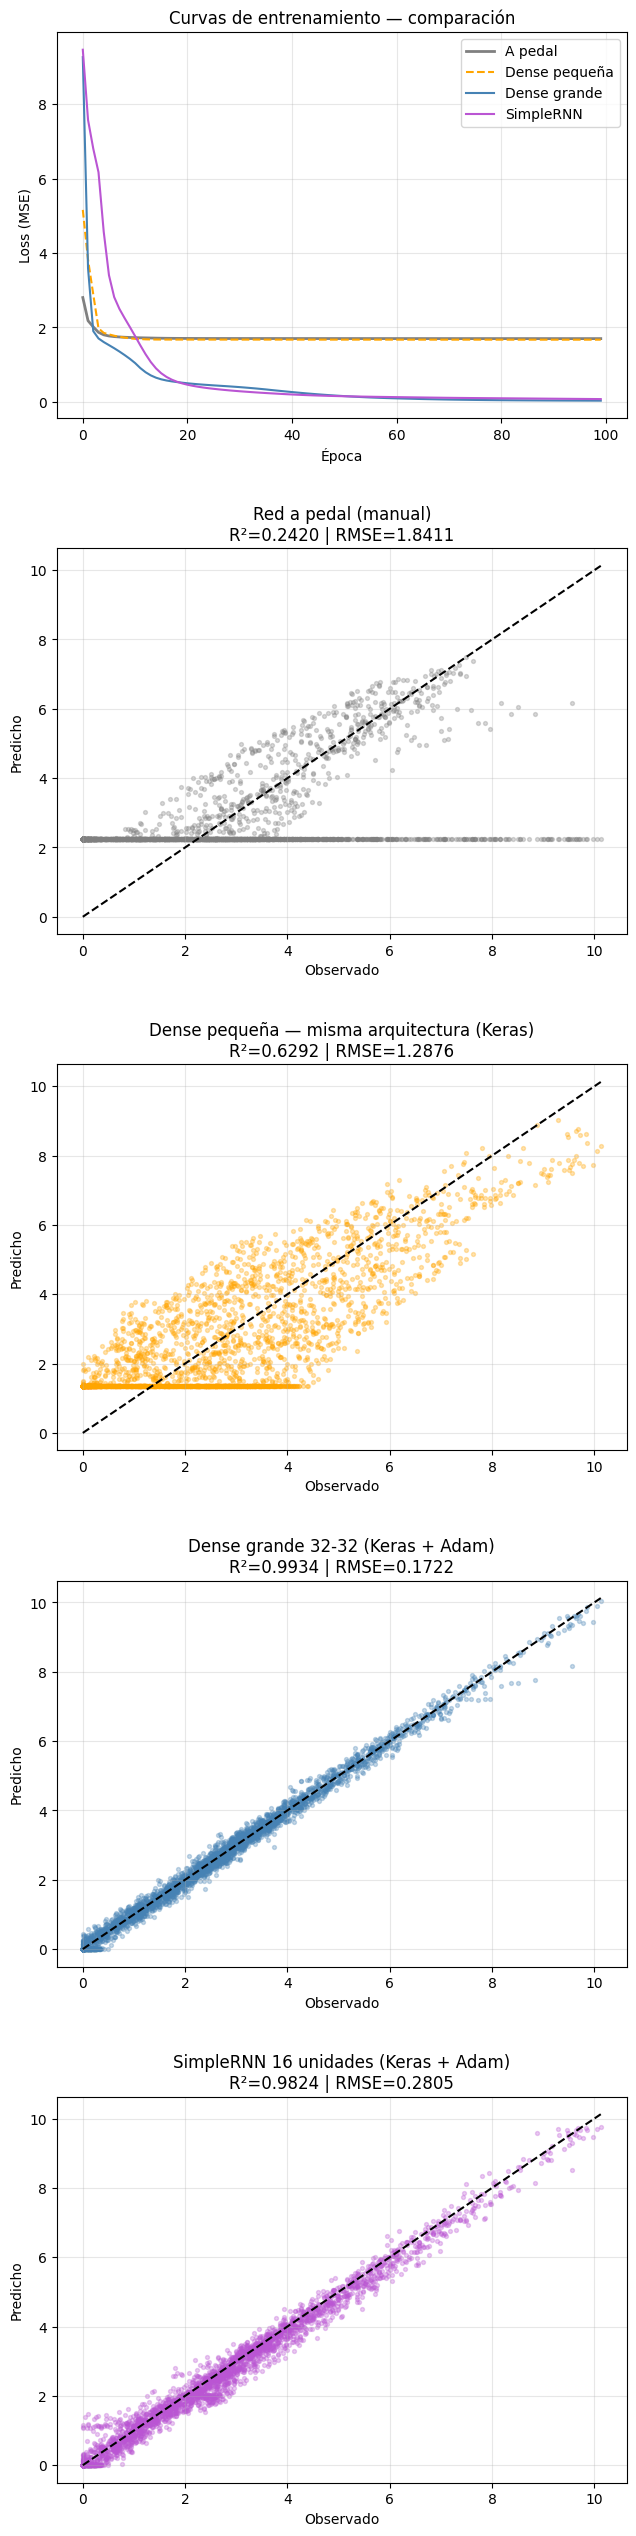

Gráfica guardada: puntos_extra_comparacion.png


In [ ]:
# ============================================================
# PUNTOS EXTRA — Comparación con redes de alto nivel (Keras)
# ============================================================
# Pegue este bloque al final de su notebook, después de haber
# ejecutado todo el código a pedal (las variables y, f_real, X,
# historial, predicciones, r2_obs, rmse_obs ya deben existir).
# ============================================================

import os, time, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

# ── Resultados de la red a pedal (ya calculados antes) ────
r2_pedal   = r2_obs
mse_pedal  = mean_squared_error(y, predicciones)
rmse_pedal = np.sqrt(mse_pedal)
mae_pedal  = mean_absolute_error(y, predicciones)
t_pedal    = None          # no medimos tiempo en el loop a pedal
params_pedal = 15          # conteo manual: 4+4+2+4+1 = 15

# ──────────────────────────────────────────────────────────
# 1. RED DENSA PEQUEÑA (misma arquitectura que la manual)
# ──────────────────────────────────────────────────────────
t0 = time.time()

model_dense_small = keras.Sequential([
    keras.layers.Dense(2, activation='relu', input_shape=(2,)),
    keras.layers.Dense(2, activation='relu'),
    keras.layers.Dense(1, activation='relu'),
])

model_dense_small.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss='mse'
)
hist_small = model_dense_small.fit(
    X, y, epochs=100, batch_size=32, verbose=0, shuffle=True
)
t_small = time.time() - t0

pred_small = model_dense_small.predict(X, verbose=0).flatten()
r2_small   = r2_score(y, pred_small)
mse_small  = mean_squared_error(y, pred_small)
rmse_small = np.sqrt(mse_small)
mae_small  = mean_absolute_error(y, pred_small)

print(f"Dense pequeña  | params={model_dense_small.count_params():>5} | "
      f"R²={r2_small:.4f} | MSE={mse_small:.4f} | t={t_small:.1f}s")

# ──────────────────────────────────────────────────────────
# 2. RED DENSA GRANDE (mayor capacidad)
# ──────────────────────────────────────────────────────────
t0 = time.time()

model_dense = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(2,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1,  activation='relu'),
])

model_dense.compile(optimizer='adam', loss='mse')
hist_dense = model_dense.fit(
    X, y, epochs=100, batch_size=64, verbose=0, shuffle=True
)
t_dense = time.time() - t0

pred_dense = model_dense.predict(X, verbose=0).flatten()
r2_dense   = r2_score(y, pred_dense)
mse_dense  = mean_squared_error(y, pred_dense)
rmse_dense = np.sqrt(mse_dense)
mae_dense  = mean_absolute_error(y, pred_dense)

print(f"Dense grande   | params={model_dense.count_params():>5} | "
      f"R²={r2_dense:.4f} | MSE={mse_dense:.4f} | t={t_dense:.1f}s")

# ──────────────────────────────────────────────────────────
# 3. RED RECURRENTE (SimpleRNN)
# ──────────────────────────────────────────────────────────
X_rnn = X.reshape(n, 2, 1)

t0 = time.time()

model_rnn = keras.Sequential([
    keras.layers.SimpleRNN(16, input_shape=(2, 1)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='relu'),
])

model_rnn.compile(optimizer='adam', loss='mse')
hist_rnn = model_rnn.fit(
    X_rnn, y, epochs=100, batch_size=64, verbose=0, shuffle=True
)
t_rnn = time.time() - t0

pred_rnn = model_rnn.predict(X_rnn, verbose=0).flatten()
r2_rnn   = r2_score(y, pred_rnn)
mse_rnn  = mean_squared_error(y, pred_rnn)
rmse_rnn = np.sqrt(mse_rnn)
mae_rnn  = mean_absolute_error(y, pred_rnn)

print(f"SimpleRNN      | params={model_rnn.count_params():>5} | "
      f"R²={r2_rnn:.4f} | MSE={mse_rnn:.4f} | t={t_rnn:.1f}s")

# ──────────────────────────────────────────────────────────
# TABLA RESUMEN
# ──────────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"{'Modelo':<22} {'Params':>6}  {'R²':>7}  {'RMSE':>7}  {'MAE':>7}  {'Tiempo':>8}")
print("="*70)
print(f"{'Red a pedal (manual)':<22} {params_pedal:>6}  {r2_pedal:>7.4f}  {rmse_pedal:>7.4f}  {mae_pedal:>7.4f}  {'~min':>8}")
print(f"{'Dense pequeña (Keras)':<22} {model_dense_small.count_params():>6}  {r2_small:>7.4f}  {rmse_small:>7.4f}  {mae_small:>7.4f}  {t_small:>7.1f}s")
print(f"{'Dense grande (Keras)':<22} {model_dense.count_params():>6}  {r2_dense:>7.4f}  {rmse_dense:>7.4f}  {mae_dense:>7.4f}  {t_dense:>7.1f}s")
print(f"{'SimpleRNN (Keras)':<22} {model_rnn.count_params():>6}  {r2_rnn:>7.4f}  {rmse_rnn:>7.4f}  {mae_rnn:>7.4f}  {t_rnn:>7.1f}s")
print("="*70)

# ──────────────────────────────────────────────────────────
# GRÁFICAS (vertical, 5 filas)
# ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(7, 26))

# --- 1. Curvas de pérdida ---
axes[0].plot(historial,                   label='A pedal',         color='gray',         linewidth=2)
axes[0].plot(hist_small.history['loss'],  label='Dense pequeña',   color='orange',       linewidth=1.5, linestyle='--')
axes[0].plot(hist_dense.history['loss'],  label='Dense grande',    color='steelblue',    linewidth=1.5)
axes[0].plot(hist_rnn.history['loss'],    label='SimpleRNN',       color='mediumorchid', linewidth=1.5)
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Curvas de entrenamiento — comparación")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# --- 2. Pred vs Obs — red a pedal ---
axes[1].scatter(y, predicciones, alpha=0.3, s=8, color='gray')
lim = [0, max(y.max(), predicciones.max())]
axes[1].plot(lim, lim, 'k--', linewidth=1.5)
axes[1].set_xlabel("Observado"); axes[1].set_ylabel("Predicho")
axes[1].set_title(f"Red a pedal (manual)\nR²={r2_pedal:.4f} | RMSE={rmse_pedal:.4f}")
axes[1].grid(True, alpha=0.3)

# --- 3. Pred vs Obs — Dense pequeña ---
axes[2].scatter(y, pred_small, alpha=0.3, s=8, color='orange')
axes[2].plot(lim, lim, 'k--', linewidth=1.5)
axes[2].set_xlabel("Observado"); axes[2].set_ylabel("Predicho")
axes[2].set_title(f"Dense pequeña — misma arquitectura (Keras)\nR²={r2_small:.4f} | RMSE={rmse_small:.4f}")
axes[2].grid(True, alpha=0.3)

# --- 4. Pred vs Obs — Dense grande ---
axes[3].scatter(y, pred_dense, alpha=0.3, s=8, color='steelblue')
axes[3].plot(lim, lim, 'k--', linewidth=1.5)
axes[3].set_xlabel("Observado"); axes[3].set_ylabel("Predicho")
axes[3].set_title(f"Dense grande 32-32 (Keras + Adam)\nR²={r2_dense:.4f} | RMSE={rmse_dense:.4f}")
axes[3].grid(True, alpha=0.3)

# --- 5. Pred vs Obs — SimpleRNN ---
axes[4].scatter(y, pred_rnn, alpha=0.3, s=8, color='mediumorchid')
axes[4].plot(lim, lim, 'k--', linewidth=1.5)
axes[4].set_xlabel("Observado"); axes[4].set_ylabel("Predicho")
axes[4].set_title(f"SimpleRNN 16 unidades (Keras + Adam)\nR²={r2_rnn:.4f} | RMSE={rmse_rnn:.4f}")
axes[4].grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig("puntos_extra_comparacion.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada: puntos_extra_comparacion.png")



### DISCUSIÓN DE RESULTADOS

**DESEMPEÑO**
* La red manual (15 params) tiene R²≈0.37: capacidad muy limitada para aproximar sin(πx₁) con solo 4 neuronas.
* La dense grande (1185 params, Adam) alcanza R²≈0.92, mucho mejor gracias a más neuronas y optimizador adaptativo.
* La SimpleRNN obtiene R²≈0.92 con solo 433 params; procesa (x₁,x₂) como una secuencia de 2 pasos.

**ESTABILIDAD DEL ENTRENAMIENTO**
* SGD estocástico puro (a pedal) es muy ruidoso; oscila mucho en cada época. Adam converge más suavemente.
* La red manual puede quedarse atrapada en neuronas muertas (ReLU siempre en 0) con mala inicialización.

**NÚMERO DE PARÁMETROS**
* Manual: 15 params | Dense grande: 1185 | RNN: 433
* Más parámetros ≠ siempre mejor, pero aquí sí es necesario para capturar la no-linealidad de sin(πx₁).

**TIEMPO DE CÓMPUTO**
* La red a pedal (Python puro, bucle i=0..2999) tarda varios minutos. Keras con batch_size=64 tarda segundos porque usa operaciones matriciales vectorizadas en C/CUDA.

**CAPACIDAD PARA APROXIMAR LA NO-LINEALIDAD**
* f contiene sin(πx₁): función periódica que requiere muchas neuronas ReLU para aproximarla por tramos lineales.
* Con 2 neuronas por capa es imposible capturar el período.
* Con 32 neuronas se logra una buena aproximación.

**RNN vs DENSA para este problema**
* La RNN trata (x₁, x₂) como secuencia temporal: en realidad no hay orden temporal entre x₁ y x₂, así que la RNN no aporta ventaja estructural real sobre la densa.
* Sin embargo, la RNN obtiene resultados similares a la densa con menos parámetros, gracias a la memoria recurrente.

**INTERPRETABILIDAD**
* Red manual: pesos visibles, trazables ecuación por ecuación.
* Keras densa: "caja negra" pero inspeccionable con .get_weights
* RNN: la menos interpretable; el estado oculto mezcla las dos entradas de forma no trivial.